In [2]:
# ── Step 1: install packages ────────────────────────────────────────────────
!pip install -q albumentations
!pip install -q timm --no-deps
!pip install -q huggingface_hub>=0.20 safetensors pyyaml

# # ── Step 2: fix CUDA/PyTorch mismatch ────────────────────────────────────────
# # PyTorch 2.2+ dropped sm_60 (P100) and sm_70 (V100) support.
# # PyTorch 2.1.2 + cu118 covers every Kaggle GPU (P100/T4/V100/A100).
# import subprocess, sys
# out = subprocess.run(
#     ['nvidia-smi', '--query-gpu=compute_cap', '--format=csv,noheader'],
#     capture_output=True, text=True)
# cc = out.stdout.strip().replace('.', '')  # e.g. '6.0' -> '60'
# print(f'GPU compute capability: sm_{cc}')

# if cc and int(cc) < 75:          # P100 (60), older Volta (70)
#     print('Installing PyTorch 2.1.2 + cu118 (supports sm_60/sm_70)...')
#     subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
#         'torch==2.1.2', 'torchvision==0.16.2',
#         '--index-url', 'https://download.pytorch.org/whl/cu118'])
# else:                             # T4 (75), A100 (80), H100 (90)
#     print('Installing PyTorch 2.3 + cu121 (supports sm_75+)...')
#     subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
#         'torch==2.3.0', 'torchvision==0.18.0',
#         '--index-url', 'https://download.pytorch.org/whl/cu121'])

# print()
# print('=' * 60)
# print('RESTART THE KERNEL NOW, then run all cells from the top.')
# print('=' * 60)


In [3]:
import os, random, warnings
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, f1_score
from tqdm.auto import tqdm
from scipy.ndimage import label as scipy_label
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [4]:
# ─── Paths ───────────────────────────────────────────────────────────────────
INPUT_DIR   = '/kaggle/input/recod-ailuc-scientific-image-forgery-detection'
TRAIN_IMGS  = f'{INPUT_DIR}/train_images'
TRAIN_MASKS = f'{INPUT_DIR}/train_masks'
SUPP_IMGS   = f'{INPUT_DIR}/supplemental_images'
SUPP_MASKS  = f'{INPUT_DIR}/supplemental_masks'
TEST_IMGS   = f'{INPUT_DIR}/test_images'

# ─── Hyperparameters ─────────────────────────────────────────────────────────
BACKBONE      = 'resnet50'   # ResNet-50 ImageNet pretrained
IMG_SIZE      = 512
BATCH_SIZE    = 8            # ResNet-50 is lighter than EfficientNet-B4/B7
MAX_EPOCHS    = 60
LR            = 3e-4
CLS_WEIGHT    = 2.0
SEG_WEIGHT    = 1.0
AUX_WEIGHT    = 0.4
CLIP_NORM     = 1.0
PATIENCE      = 12
VAL_FRAC      = 0.15
SEED          = 42
BEST_PATH     = 'best_model_v3.pt'
DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    cap = torch.cuda.get_device_capability(0)
    print(f'GPU     : {torch.cuda.get_device_name(0)}  (sm_{cap[0]}{cap[1]})')


Device: cuda


In [5]:
# ─── Dataset ─────────────────────────────────────────────────────────────────

def load_mask_npy(path, target_h, target_w):
    """Load .npy mask; handle multi-mask [N,H,W] by union; resize to target."""
    m = np.load(path)
    if m.ndim == 3:
        m = m.max(axis=0)          # union of all duplicated regions
    if m.shape != (target_h, target_w):
        m = cv2.resize(m.astype(np.float32), (target_w, target_h),
                       interpolation=cv2.INTER_NEAREST)
    return (m > 0).astype(np.float32)


class ForgeryDataset(Dataset):
    def __init__(self, samples, transform=None):
        """
        samples: list of dicts with keys:
            img   - path to image
            label - 0 (authentic) or 1 (forged)
            mask  - path to .npy mask (or None for authentic)
        """
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(s['img']), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        if s['label'] == 1 and s['mask'] is not None:
            mask = load_mask_npy(s['mask'], h, w)
        else:
            mask = np.zeros((h, w), dtype=np.float32)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask']

        label = torch.tensor(s['label'], dtype=torch.float32)
        return img, label, mask.unsqueeze(0)  # mask: [1, H, W]


def build_sample_list():
    """Scan all sources and return (samples, uid_list_for_splitting)."""
    samples  = []
    all_uids = []

    # ── Main train set (paired authentic / forged) ────────────────────────
    auth_dir  = f'{TRAIN_IMGS}/authentic'
    forg_dir  = f'{TRAIN_IMGS}/forged'
    auth_uids = {os.path.splitext(f)[0] for f in os.listdir(auth_dir) if f.endswith('.png')}
    forg_uids = {os.path.splitext(f)[0] for f in os.listdir(forg_dir) if f.endswith('.png')}
    paired    = sorted(auth_uids & forg_uids)

    for uid in paired:
        all_uids.append(uid)
        samples.append({'uid': uid, 'img': f'{auth_dir}/{uid}.png',
                        'label': 0, 'mask': None})
        mask_path = f'{TRAIN_MASKS}/{uid}.npy'
        if os.path.exists(mask_path):
            samples.append({'uid': uid, 'img': f'{forg_dir}/{uid}.png',
                            'label': 1, 'mask': mask_path})

    # ── Supplemental (forged only, always in train) ───────────────────────
    if os.path.isdir(SUPP_IMGS):
        for fname in sorted(os.listdir(SUPP_IMGS)):
            if not fname.endswith('.png'):
                continue
            uid       = os.path.splitext(fname)[0]
            mask_path = f'{SUPP_MASKS}/{uid}.npy'
            if os.path.exists(mask_path):
                samples.append({'uid': uid, 'img': f'{SUPP_IMGS}/{fname}',
                                'label': 1, 'mask': mask_path,
                                'supplemental': True})

    return samples, all_uids

In [6]:
# ─── Build train / val splits ────────────────────────────────────────────────

all_samples, all_uids = build_sample_list()

# Split by UID so authentic/forged pairs never straddle the boundary
shuffled      = sorted(all_uids)
random.shuffle(shuffled)
n_val         = int(VAL_FRAC * len(shuffled))
val_uid_set   = set(shuffled[:n_val])
train_uid_set = set(shuffled[n_val:])

train_samples = [s for s in all_samples
                 if s.get('supplemental') or s['uid'] in train_uid_set]
val_samples   = [s for s in all_samples if s['uid'] in val_uid_set]

print(f'Train: {len(train_samples)}  '
      f'(auth={sum(s["label"]==0 for s in train_samples)}, '
      f'forg={sum(s["label"]==1 for s in train_samples)})')
print(f'Val  : {len(val_samples)}  '
      f'(auth={sum(s["label"]==0 for s in val_samples)}, '
      f'forg={sum(s["label"]==1 for s in val_samples)})')

Train: 4090  (auth=2021, forg=2069)
Val  : 713  (auth=356, forg=357)


In [7]:
# ─── Transforms ──────────────────────────────────────────────────────────────

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = A.Compose([
    A.RandomResizedCrop((IMG_SIZE, IMG_SIZE), scale=(0.5, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.OneOf([
        A.RandomBrightnessContrast(0.2, 0.2),
        A.HueSaturationValue(10, 20, 10),
        A.CLAHE(clip_limit=2.0),
    ], p=0.6),
    A.ImageCompression(quality_lower=70, quality_upper=100, p=0.3),
    A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

val_tf = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

test_tf = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

In [8]:
# ─── DataLoaders ─────────────────────────────────────────────────────────────

train_ds = ForgeryDataset(train_samples, train_tf)
val_ds   = ForgeryDataset(val_samples,   val_tf)

# WeightedRandomSampler for class balance
train_labels   = [s['label'] for s in train_samples]
class_counts   = np.bincount(train_labels)
sample_weights = [1.0 / class_counts[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

In [9]:
# ─── Model: ResNet-50 + CBAM-UNet decoder ────────────────────────────────────
#
# ResNet-50 feature map channels (timm features_only=True):
#   f0 :  64 ch @ stride-2  (stem, 256×256 for 512-px input)
#   f1 : 256 ch @ stride-4  (layer1, 128×128)
#   f2 : 512 ch @ stride-8  (layer2,  64×64)
#   f3 :1024 ch @ stride-16 (layer3,  32×32)
#   f4 :2048 ch @ stride-32 (layer4,  16×16)


class CBAM(nn.Module):
    """Convolutional Block Attention Module (channel + spatial attention)."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = max(channels // reduction, 4)
        self.fc = nn.Sequential(
            nn.Linear(channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels, bias=False),
        )
        self.spatial = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)

    def forward(self, x):
        b, c = x.shape[:2]
        # Channel attention
        avg = self.fc(F.adaptive_avg_pool2d(x, 1).view(b, c)).view(b, c, 1, 1)
        mx  = self.fc(F.adaptive_max_pool2d(x, 1).view(b, c)).view(b, c, 1, 1)
        x   = x * torch.sigmoid(avg + mx)
        # Spatial attention
        avg_s = x.mean(dim=1, keepdim=True)
        max_s = x.max(dim=1, keepdim=True)[0]
        x     = x * torch.sigmoid(self.spatial(torch.cat([avg_s, max_s], dim=1)))
        return x


class ConvBNReLU(nn.Sequential):
    def __init__(self, in_c, out_c, k=3, p=1):
        super().__init__(
            nn.Conv2d(in_c, out_c, k, padding=p, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )


class DecoderBlock(nn.Module):
    """Upsample x2 → concat skip → 2×ConvBNReLU → CBAM attention."""
    def __init__(self, in_c, skip_c, out_c):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv = nn.Sequential(
            ConvBNReLU(in_c + skip_c, out_c),
            ConvBNReLU(out_c, out_c),
        )
        self.cbam = CBAM(out_c)

    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            x = torch.cat([x, skip], dim=1)
        return self.cbam(self.conv(x))


class ResNetUNet(nn.Module):
    """
    ResNet-50 encoder + CBAM-UNet decoder with deep supervision.

    The encoder is loaded via timm (features_only=True) so channel widths
    are inferred at construction time from feature_info.channels().

    Outputs
    -------
    cls_out  : [B, 1]           classification logit
    seg_out  : [B, 1, H, W]     full-resolution segmentation logit
    aux4_out : [B, 1, H/16, W/16]  deep-supervision head at decoder level 4
    aux3_out : [B, 1, H/8,  W/8 ]  deep-supervision head at decoder level 3
    """

    def __init__(self, backbone: str = BACKBONE, pretrained: bool = True):
        super().__init__()
        self.encoder = timm.create_model(
            backbone, pretrained=pretrained, features_only=True)
        ch = self.encoder.feature_info.channels()   # [64, 256, 512, 1024, 2048]

        # Decoder: each block halves the spatial bottleneck channel count
        self.d4 = DecoderBlock(ch[4], ch[3], 256)  # 2048+1024 → 256
        self.d3 = DecoderBlock(256,   ch[2], 128)  #  256+ 512 → 128
        self.d2 = DecoderBlock(128,   ch[1],  64)  #  128+ 256 →  64
        self.d1 = DecoderBlock( 64,   ch[0],  32)  #   64+  64 →  32
        self.d0 = DecoderBlock( 32,       0,  16)  #   32      →  16  (no skip)

        # Output heads
        self.seg_head  = nn.Conv2d(16,  1, kernel_size=1)
        self.aux4_head = nn.Conv2d(256, 1, kernel_size=1)
        self.aux3_head = nn.Conv2d(128, 1, kernel_size=1)

        # Classification head: global pool on deepest feature map
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(ch[4], 512),   # ch[4] = 2048 for ResNet-50
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 1),
        )

    def forward(self, x):
        f0, f1, f2, f3, f4 = self.encoder(x)
        cls_out = self.cls_head(f4)
        d4  = self.d4(f4, f3)
        d3  = self.d3(d4, f2)
        d2  = self.d2(d3, f1)
        d1  = self.d1(d2, f0)
        d0  = self.d0(d1)
        return cls_out, self.seg_head(d0), self.aux4_head(d4), self.aux3_head(d3)


In [10]:
# ─── Loss functions ───────────────────────────────────────────────────────────

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p   = torch.sigmoid(logits)
        pt  = targets * p + (1 - targets) * (1 - p)
        at  = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        return (at * (1 - pt) ** self.gamma * bce).mean()


def tversky_loss(logits, targets, alpha=0.3, beta=0.7, eps=1e-7):
    p  = torch.sigmoid(logits)
    tp = (p * targets).sum()
    fp = (p * (1 - targets)).sum()
    fn = ((1 - p) * targets).sum()
    return 1 - (tp + eps) / (tp + alpha * fp + beta * fn + eps)


def seg_loss_fn(pred, gt):
    return F.binary_cross_entropy_with_logits(pred, gt) + tversky_loss(pred, gt)


_focal_cls = FocalLoss(alpha=0.5, gamma=2.0)


def multitask_loss(cls_out, seg_out, aux4, aux3, labels, masks):
    cls_loss = _focal_cls(cls_out.squeeze(1), labels)

    seg_total = torch.tensor(0.0, device=cls_out.device)
    forged    = labels == 1
    if forged.any():
        gt_d4 = F.adaptive_avg_pool2d(masks[forged], aux4.shape[-2:])
        gt_d3 = F.adaptive_avg_pool2d(masks[forged], aux3.shape[-2:])
        seg_total = (seg_loss_fn(seg_out[forged], masks[forged])
                     + AUX_WEIGHT * seg_loss_fn(aux4[forged], gt_d4)
                     + AUX_WEIGHT * seg_loss_fn(aux3[forged], gt_d3))

    total = CLS_WEIGHT * cls_loss + SEG_WEIGHT * seg_total
    return total, cls_loss.detach(), seg_total.detach()

In [11]:
# ─── Train / Validate ────────────────────────────────────────────────────────

# AMP only on Ampere+ (sm_80+); older GPUs (P100=sm_60, T4=sm_75) may lack fp16 kernels
_gpu_major = torch.cuda.get_device_capability(0)[0] if torch.cuda.is_available() else 0
USE_AMP    = _gpu_major >= 8
scaler     = torch.amp.GradScaler('cuda') if USE_AMP else None
print(f'AMP enabled: {USE_AMP}  (GPU compute capability sm_{_gpu_major}x)')


def train_one_epoch(model, loader, optimizer, epoch):
    model.train()
    losses, cls_ls, seg_ls = [], [], []
    pbar = tqdm(loader, desc=f'Epoch {epoch:02d} [Train]')
    for imgs, labels, masks in pbar:
        imgs, labels, masks = imgs.to(DEVICE), labels.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        if USE_AMP:
            with torch.amp.autocast('cuda'):
                cls_out, seg_out, aux4, aux3 = model(imgs)
                loss, cl, sl = multitask_loss(cls_out, seg_out, aux4, aux3, labels, masks)
        else:
            cls_out, seg_out, aux4, aux3 = model(imgs)
            loss, cl, sl = multitask_loss(cls_out, seg_out, aux4, aux3, labels, masks)
        if not torch.isfinite(loss):
            optimizer.zero_grad()
            continue
        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
            optimizer.step()
        losses.append(loss.item())
        cls_ls.append(cl.item())
        seg_ls.append(sl.item())
        pbar.set_postfix({'loss': f'{np.mean(losses):.4f}',
                          'cls':  f'{np.mean(cls_ls):.4f}',
                          'seg':  f'{np.mean(seg_ls):.4f}'})
    return float(np.mean(losses)), float(np.mean(cls_ls)), float(np.mean(seg_ls))


@torch.no_grad()
def validate(model, loader, threshold=0.5):
    model.train(False)
    y_true, y_prob, dice_scores = [], [], []
    for imgs, labels, masks in tqdm(loader, desc='Val', leave=False):
        imgs, labels, masks = imgs.to(DEVICE), labels.to(DEVICE), masks.to(DEVICE)
        cls_out, seg_out, _, _ = model(imgs)
        probs = torch.sigmoid(cls_out).squeeze(1)
        y_true.extend(labels.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())
        for i in range(len(labels)):
            if labels[i].item() == 1:
                pred  = (torch.sigmoid(seg_out[i, 0]) > threshold).float()
                gt    = masks[i, 0]
                inter = (pred * gt).sum()
                dice_scores.append((2 * inter / (pred.sum() + gt.sum() + 1e-7)).item())
    model.train()
    y_pred = [1 if p > threshold else 0 for p in y_prob]
    acc    = accuracy_score(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = 0.5
    dice  = float(np.mean(dice_scores)) if dice_scores else 0.0
    cm    = confusion_matrix(y_true, y_pred)
    fgrec = cm[1, 1] / (cm[1, 0] + cm[1, 1] + 1e-7) if cm.shape == (2, 2) else 0.0
    comp  = 0.4 * auc + 0.3 * fgrec + 0.3 * dice
    return {'acc': acc, 'auc': auc, 'dice': dice, 'fgrec': fgrec, 'comp': comp}

AMP enabled: False  (GPU compute capability sm_6x)


In [12]:
# ─── Model + Optimizer ───────────────────────────────────────────────────────

model = ResNetUNet(backbone=BACKBONE, pretrained=True).to(DEVICE)

enc_params = list(model.encoder.parameters())
dec_params = [p for n, p in model.named_parameters() if not n.startswith('encoder')]

optimizer = torch.optim.AdamW([
    {'params': enc_params, 'lr': LR * 0.1},   # encoder: 10x lower LR
    {'params': dec_params, 'lr': LR},          # decoder: full LR
], weight_decay=1e-4)

warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
cosine_sched = CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS - 5, eta_min=LR * 0.01)
scheduler    = SequentialLR(optimizer, [warmup_sched, cosine_sched], milestones=[5])

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Backbone        : {BACKBONE}')
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}')
print(f'Encoder LR      : {LR * 0.1:.2e}  |  Decoder LR: {LR:.2e}')


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Total params: 19,654,662


In [16]:
# ─── Training loop ────────────────────────────────────────────────────────────

history, best_comp, patience_ctr = [], -float('inf'), 0

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_cls, tr_seg = train_one_epoch(model, train_loader, optimizer, epoch)
    val_m = validate(model, val_loader)
    scheduler.step()

    history.append({'epoch': epoch, 'tr_loss': tr_loss,
                    **{f'val_{k}': v for k, v in val_m.items()}})
    print(f'[{epoch:02d}] Loss={tr_loss:.4f} cls={tr_cls:.4f} seg={tr_seg:.4f} | '
          f'Acc={val_m["acc"]:.4f} AUC={val_m["auc"]:.4f} '
          f'Dice={val_m["dice"]:.4f} FgRec={val_m["fgrec"]:.4f} '
          f'Comp={val_m["comp"]:.4f}')

    if val_m['comp'] > best_comp:
        best_comp    = val_m['comp']
        patience_ctr = 0
        torch.save(model.state_dict(), BEST_PATH)
        print(f'  Best model saved (comp={best_comp:.4f})')
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

Epoch 01 [Train]:   0%|          | 0/1023 [00:00<?, ?it/s]

Val:   0%|          | 0/179 [00:00<?, ?it/s]

[01] Loss=2.3851 cls=0.0994 seg=2.1863 | Acc=0.5077 AUC=0.5140 Dice=0.1788 FgRec=0.2549 Comp=0.3357
  Best model saved (comp=0.3357)


Epoch 02 [Train]:   0%|          | 0/1023 [00:00<?, ?it/s]

Val:   0%|          | 0/179 [00:00<?, ?it/s]

...

Val:   0%|          | 0/179 [00:00<?, ?it/s]

[30] Loss=1.1945 cls=0.0710 seg=1.0526 | Acc=0.7363 AUC=0.8371 Dice=0.4246 FgRec=0.5714 Comp=0.6337


Epoch 31 [Train]:   0%|          | 0/1023 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e564418f880>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1628, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
    

KeyboardInterrupt: 

In [17]:
# ─── Load best checkpoint + comprehensive evaluation ─────────────────────────
import os, time
import seaborn as sns
from sklearn.metrics import roc_curve, classification_report

# ── 1. Checkpoint diagnostics ────────────────────────────────────────────────
if os.path.exists(BEST_PATH):
    mtime = os.path.getmtime(BEST_PATH)
    size  = os.path.getsize(BEST_PATH) / 1e6
    print(f'Checkpoint : {BEST_PATH}')
    print(f'Modified   : {time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(mtime))}')
    print(f'Size       : {size:.1f} MB')
else:
    raise FileNotFoundError(f'Checkpoint not found: {BEST_PATH}')

# ── 2. Load checkpoint ────────────────────────────────────────────────────────
ckpt = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    model.load_state_dict(ckpt['model_state_dict'])
    saved_meta = {k: v for k, v in ckpt.items() if k != 'model_state_dict'}
    print(f'Checkpoint meta: {saved_meta}')
else:
    model.load_state_dict(ckpt)
    print('Loaded raw state_dict (no metadata)')
model.eval()

# ── 3. Collect predictions ────────────────────────────────────────────────────
y_true_all, y_prob_all = [], []
with torch.no_grad():
    for imgs, labels, _ in val_loader:
        cls_out, _, _, _ = model(imgs.to(DEVICE))
        y_prob_all.extend(torch.sigmoid(cls_out).squeeze(1).cpu().numpy())
        y_true_all.extend(labels.numpy())

y_true_all = np.array(y_true_all)
y_prob_all = np.array(y_prob_all)

# Quick AUC sanity check before threshold search
quick_auc = roc_auc_score(y_true_all, y_prob_all)
print(f'\nQuick AUC (raw probs, no threshold): {quick_auc:.4f}')
if quick_auc < 0.55:
    print('WARNING: AUC < 0.55 — checkpoint may be from an early/bad epoch.')
    print('         Check the modification time above vs your training run.')

# ── 4. Find optimal threshold via F1 sweep ────────────────────────────────────
best_thr, best_f1 = 0.5, 0.0
for thr in np.arange(0.05, 0.95, 0.01):
    preds = (y_prob_all > thr).astype(int)
    f1    = f1_score(y_true_all, preds, zero_division=0)
    if f1 > best_f1:
        best_f1, best_thr = f1, float(thr)

y_pred_all = (y_prob_all > best_thr).astype(int)
cm = confusion_matrix(y_true_all, y_pred_all)
tn, fp, fn, tp = cm.ravel()

print(f'\nBest threshold : {best_thr:.2f}  (F1={best_f1:.4f})')

# ── 5. Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 5a. Probability distribution by class
ax = axes[0]
ax.hist(y_prob_all[y_true_all == 0], bins=40, alpha=0.6, color='steelblue',  label='Authentic')
ax.hist(y_prob_all[y_true_all == 1], bins=40, alpha=0.6, color='tomato',     label='Forged')
ax.axvline(best_thr, color='k', linestyle='--', linewidth=1.5, label=f'thr={best_thr:.2f}')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Count')
ax.set_title('Score Distribution')
ax.legend()

# 5b. Confusion matrix
ax = axes[1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Authentic', 'Forged'],
            yticklabels=['Authentic', 'Forged'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix  (thr={best_thr:.2f})')

# 5c. ROC curve
ax = axes[2]
fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
ax.plot(fpr, tpr, lw=2, label=f'AUC = {quick_auc:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve'); ax.legend()

plt.tight_layout()
plt.show()

# ── 6. Text metrics ───────────────────────────────────────────────────────────
print(f'Accuracy    : {accuracy_score(y_true_all, y_pred_all):.4f}')
print(f'AUC         : {quick_auc:.4f}')
print(f'Precision   : {tp / (tp + fp + 1e-7):.4f}')
print(f'Recall      : {tp / (tp + fn + 1e-7):.4f}  (Forged / Sensitivity)')
print(f'Specificity : {tn / (tn + fp + 1e-7):.4f}  (Authentic / Specificity)')
print(f'F1          : {2*tp / (2*tp + fp + fn + 1e-7):.4f}')
print()
print(classification_report(y_true_all, y_pred_all,
                             target_names=['Authentic', 'Forged']))


Best threshold: 0.40  (F1=0.7612)


Val:   0%|          | 0/179 [00:00<?, ?it/s]

Final val — AUC=0.8433  Acc=0.7167  Dice=0.5043  FgRec=0.9020  Comp=0.7592


In [18]:
# ─── Post-processing ─────────────────────────────────────────────────────────

def postprocess_mask(prob_map, threshold=0.5, min_area=200):
    """Binarise, morphological close, remove small components."""
    binary = (prob_map > threshold).astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    labeled, n = scipy_label(binary)
    out = np.zeros_like(binary)
    for i in range(1, n + 1):
        if (labeled == i).sum() >= min_area:
            out[labeled == i] = 1
    return out.astype(np.float32)


# ─── TTA inference ───────────────────────────────────────────────────────────

@torch.no_grad()
def tta_predict(model, img_tensor):
    """img_tensor: [1, C, H, W]. Returns (cls_prob float, seg_map np HxW)."""
    flips = [
        img_tensor,
        torch.flip(img_tensor, dims=[-1]),     # horizontal
        torch.flip(img_tensor, dims=[-2]),     # vertical
        torch.flip(img_tensor, dims=[-1, -2]), # both
    ]
    cls_preds, seg_preds = [], []
    for i, v in enumerate(flips):
        cls_out, seg_out, _, _ = model(v)
        cls_preds.append(torch.sigmoid(cls_out).item())
        sp = torch.sigmoid(seg_out[0, 0]).cpu().numpy()
        if i == 1: sp = sp[:, ::-1].copy()
        if i == 2: sp = sp[::-1, :].copy()
        if i == 3: sp = sp[::-1, ::-1].copy()
        seg_preds.append(sp)
    return float(np.mean(cls_preds)), np.mean(seg_preds, axis=0)

In [19]:
# ─── Submission skipped — inference-only mode ────────────────────────────────
# Use predict_image() below to run single-image inference.
print('Submission CSV skipped. Use predict_image() for inference.')


Submission CSV skipped. Use predict_image() for inference.


In [20]:
# ─── Save final model bundle ─────────────────────────────────────────────────

torch.save({
    'model_state_dict': model.state_dict(),
    'cls_threshold':    best_thr,
    'seg_threshold':    best_thr,
    'img_size':         IMG_SIZE,
    'backbone':         BACKBONE,
    'architecture':     'ResNet50-CBAM-UNet-DeepSupervision',
    'val_comp':         best_comp,
}, 'final_model_v3.pt')
print('final_model_v3.pt saved.')


final_model_v3.pt saved.


In [21]:
# ─── Single-image inference with B&W forgery map ─────────────────────────────

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])


def show_bw_mask(mask_np, title='Forgery Mask (B&W)'):
    """Display a standalone black-and-white forgery mask."""
    plt.figure(figsize=(5, 5))
    plt.imshow(mask_np, cmap='gray', vmin=0, vmax=1)
    plt.title(title, fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


def predict_image(image_path, cls_threshold=None, seg_threshold=None,
                  min_area=200, show=True, save_prefix=None):
    """
    Run inference on a single image.

    Parameters
    ----------
    image_path   : str   path to the PNG/JPG image
    cls_threshold: float classification threshold (default: best_thr)
    seg_threshold: float segmentation threshold   (default: best_thr)
    min_area     : int   smallest kept forgery region in pixels
    show         : bool  display plots inline
    save_prefix  : str   if set, save plots to '<save_prefix>_overlay.png'
                         and '<save_prefix>_mask.png'

    Returns
    -------
    dict with keys: label (str), cls_prob (float), mask (np.ndarray H×W)
    """
    if cls_threshold is None: cls_threshold = best_thr
    if seg_threshold is None: seg_threshold = best_thr

    img            = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    orig_h, orig_w = img.shape[:2]
    tensor         = test_tf(image=img)['image'].unsqueeze(0).to(DEVICE)

    cls_prob, seg_np = tta_predict(model, tensor)
    label            = 'Forged' if cls_prob > cls_threshold else 'Authentic'
    mask_small       = postprocess_mask(seg_np, seg_threshold, min_area)
    mask             = cv2.resize(mask_small, (orig_w, orig_h),
                                  interpolation=cv2.INTER_NEAREST)

    if show:
        if label == 'Authentic':
            # ── Authentic: single panel ───────────────────────────────────
            fig, ax = plt.subplots(figsize=(6, 5))
            ax.imshow(img)
            ax.set_title(f'Authentic  (confidence: {1 - cls_prob:.1%})', fontsize=13)
            ax.axis('off')
            plt.tight_layout()
            if save_prefix:
                plt.savefig(f'{save_prefix}_authentic.png', dpi=150, bbox_inches='tight')
            plt.show()
        else:
            # ── Forged: 3-panel layout ────────────────────────────────────
            overlay         = img.copy()
            overlay[mask > 0] = (np.array([255, 50, 50]) * 0.6
                                 + overlay[mask > 0] * 0.4).astype(np.uint8)

            fig, axes = plt.subplots(1, 3, figsize=(18, 5))

            axes[0].imshow(img)
            axes[0].set_title(f'Input image', fontsize=13)
            axes[0].axis('off')

            axes[1].imshow(overlay)
            axes[1].set_title(f'Forged region highlighted  (p={cls_prob:.3f})',
                              fontsize=13)
            axes[1].axis('off')

            axes[2].imshow(mask, cmap='gray', vmin=0, vmax=1)
            axes[2].set_title('Forgery mask (B&W)', fontsize=13)
            axes[2].axis('off')

            plt.tight_layout()
            if save_prefix:
                plt.savefig(f'{save_prefix}_overlay.png', dpi=150,
                            bbox_inches='tight')
            plt.show()

            # ── Standalone B&W mask plot ──────────────────────────────────
            fig2, ax2 = plt.subplots(figsize=(5, 5))
            ax2.imshow(mask, cmap='gray', vmin=0, vmax=1)
            ax2.set_title('Forgery mask (B&W)', fontsize=13)
            ax2.axis('off')
            plt.tight_layout()
            if save_prefix:
                plt.savefig(f'{save_prefix}_mask.png', dpi=150,
                            bbox_inches='tight')
            plt.show()

    return {'label': label, 'cls_prob': cls_prob, 'mask': mask}


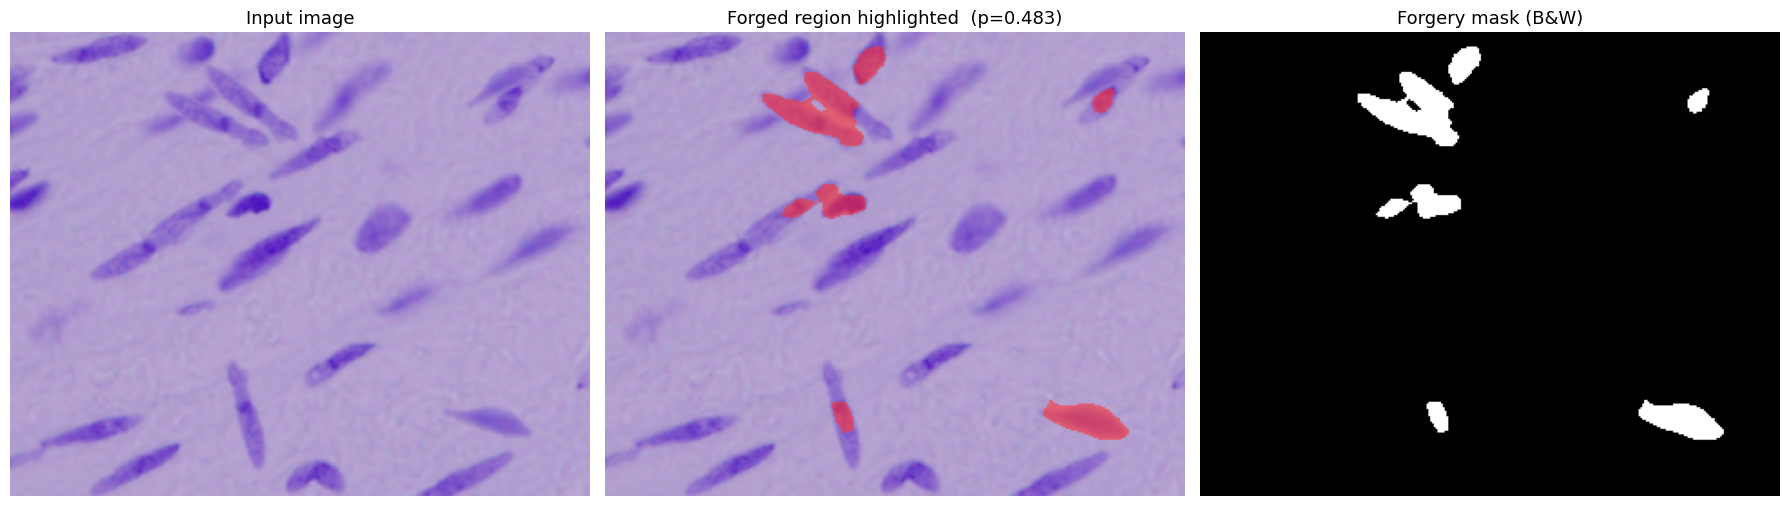

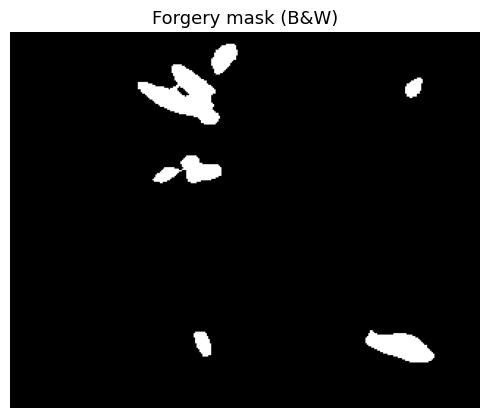

Label    : Forged
Confidence: 0.4827
Forged px: 3.3% of image


In [30]:
# ─── Run inference on any image ───────────────────────────────────────────────
# Change IMAGE_PATH to the image you want to predict.

IMAGE_PATH = '/kaggle/input/recod-ailuc-scientific-image-forgery-detection/test_images/45.png'

result = predict_image(
    IMAGE_PATH,
    cls_threshold=best_thr,  # or override, e.g. 0.4
    seg_threshold=best_thr,
    min_area=200,
    show=True,
    # save_prefix='output/result_45',  # uncomment to save PNGs
)

print(f"Label    : {result['label']}")
print(f"Confidence: {result['cls_prob']:.4f}")
if result['label'] == 'Forged':
    pct = result['mask'].mean() * 100
    print(f"Forged px: {pct:.1f}% of image")


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# ─── EVALUATION: Confusion Matrix, ROC Curve & Metrics ──────────────────────
# ═══════════════════════════════════════════════════════════════════════════
# Run this cell after training to evaluate the best saved checkpoint.
# It is self-contained: loads the checkpoint, sweeps threshold, plots everything.

import os, time
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    f1_score, roc_curve, classification_report
)
BEST_PATH = "/kaggle/input/models/jayavikramprakash/jp/pytorch/default/1/final_model_v3.pt"
# ── 1. Checkpoint info ───────────────────────────────────────────────────────
if not os.path.exists(BEST_PATH):
    raise FileNotFoundError(f'No checkpoint found at {BEST_PATH}. Run training first.')

mtime = os.path.getmtime(BEST_PATH)
size  = os.path.getsize(BEST_PATH) / 1e6
print(f'Checkpoint : {BEST_PATH}')
print(f'Modified   : {time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(mtime))}')
print(f'Size       : {size:.1f} MB')

# ── 2. Load weights ──────────────────────────────────────────────────────────
ckpt = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    model.load_state_dict(ckpt['model_state_dict'])
    meta = {k: v for k, v in ckpt.items() if k != 'model_state_dict'}
    print(f'Saved meta : {meta}')
else:
    model.load_state_dict(ckpt)
model.eval()

# ── 3. Collect val predictions ───────────────────────────────────────────────
y_true_ev, y_prob_ev = [], []
with torch.no_grad():
    for imgs, labels, _ in val_loader:
        cls_out, _, _, _ = model(imgs.to(DEVICE))
        y_prob_ev.extend(torch.sigmoid(cls_out).squeeze(1).cpu().numpy())
        y_true_ev.extend(labels.numpy())

y_true_ev = np.array(y_true_ev)
y_prob_ev = np.array(y_prob_ev)

auc = roc_auc_score(y_true_ev, y_prob_ev)
print(f'\nAUC (threshold-free): {auc:.4f}')
if auc < 0.55:
    print('  ⚠ AUC < 0.55 — checkpoint may be from an early epoch or wrong file.')

# ── 4. Optimal threshold (F1 sweep) ──────────────────────────────────────────
best_thr, best_f1 = 0.5, 0.0
for thr in np.arange(0.05, 0.95, 0.01):
    preds = (y_prob_ev > thr).astype(int)
    f1 = f1_score(y_true_ev, preds, zero_division=0)
    if f1 > best_f1:
        best_f1, best_thr = f1, float(thr)

y_pred_ev = (y_prob_ev > best_thr).astype(int)
cm = confusion_matrix(y_true_ev, y_pred_ev)
tn, fp, fn, tp = cm.ravel()
print(f'Best threshold      : {best_thr:.2f}  (F1={best_f1:.4f})')

# ── 5. Figures (3 panels) ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Validation Evaluation', fontsize=14, fontweight='bold')

# Panel A — Score distribution
ax = axes[0]
ax.hist(y_prob_ev[y_true_ev == 0], bins=40, alpha=0.65,
        color='steelblue', label=f'Authentic (n={int((y_true_ev==0).sum())})')
ax.hist(y_prob_ev[y_true_ev == 1], bins=40, alpha=0.65,
        color='tomato',    label=f'Forged    (n={int((y_true_ev==1).sum())})')
ax.axvline(best_thr, color='black', linestyle='--', lw=1.5,
           label=f'threshold={best_thr:.2f}')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Count')
ax.set_title('Score Distribution')
ax.legend(fontsize=8)

# Panel B — Confusion matrix
ax = axes[1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Authentic', 'Forged'],
            yticklabels=['Authentic', 'Forged'],
            annot_kws={'size': 14})
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title(f'Confusion Matrix  (thr={best_thr:.2f})')

# Panel C — ROC curve
ax = axes[2]
fpr, tpr, _ = roc_curve(y_true_ev, y_prob_ev)
ax.plot(fpr, tpr, lw=2, color='darkorange', label=f'AUC = {auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color='darkorange')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# ── 6. Printed metrics ───────────────────────────────────────────────────────
print('=' * 45)
print(f'  Accuracy    : {accuracy_score(y_true_ev, y_pred_ev):.4f}')
print(f'  AUC         : {auc:.4f}')
print(f'  Precision   : {tp / (tp + fp + 1e-7):.4f}')
print(f'  Recall      : {tp / (tp + fn + 1e-7):.4f}  (Forged sensitivity)')
print(f'  Specificity : {tn / (tn + fp + 1e-7):.4f}  (Authentic recall)')
print(f'  F1          : {2*tp / (2*tp + fp + fn + 1e-7):.4f}')
print('=' * 45)
print()
print(classification_report(y_true_ev, y_pred_ev,
                             target_names=['Authentic', 'Forged']))


Checkpoint : /kaggle/input/models/jayavikramprakash/jp/pytorch/default/1/final_model_v3.pt
Modified   : 2026-04-04 01:20:56
Size       : 79.4 MB


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 